<a href="https://colab.research.google.com/github/re-side/ml_basic/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_K_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B8%D1%85_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Метод K-ближайших соседей**

Для всех классификаторов из Sklearn подбирайте лучшие гиперпараметры для модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

# **Базовый алгоритм KNN**

## **KNN для классификации**

### **Получение данных**

Будем работать с набором данным `iris` из `sklearn`.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 1.2. Обучите модель KNN

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

KNeighborsClassifier()

#### 1.3. Проверьте качество работы модели

In [16]:
from sklearn.metrics import accuracy_score

preds = knn.predict(X_test)

acc = accuracy_score(y_test, preds)
print(f"Точность (accuracy): {acc:.2f}")

Точность (accuracy): 1.00


#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

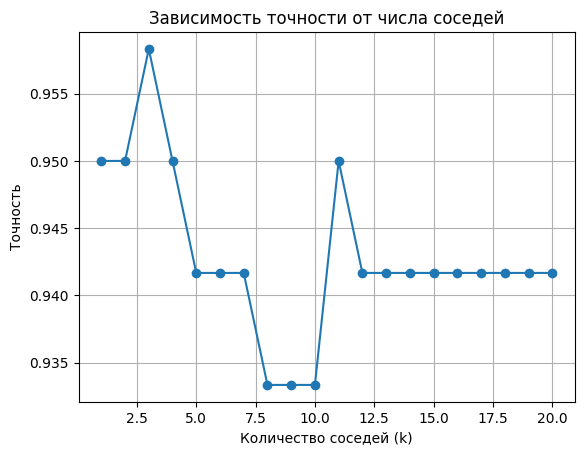

Самое оптимальное значение k: 3


In [17]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

params = {'n_neighbors': range(1, 21)}

grid = GridSearchCV(KNeighborsClassifier(), params, cv=5)
grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_)
plt.plot(results['param_n_neighbors'], results['mean_test_score'], marker='o')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность')
plt.title('Зависимость точности от числа соседей')
plt.grid()
plt.show()

print(f"Самое оптимальное значение k: {grid.best_params_['n_neighbors']}")

### **2. KNN рукописный**

#### 2.1. Возьмите два случайных тестовых объектов

In [ ]:
# Ваш код здесь


#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [ ]:
# Ваш код здесь


#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [ ]:
# Ваш код здесь


#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [ ]:
# Ваш код здесь


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [ ]:
# Ваш код здесь


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### **KNN из sklearn**

#### 3.1. Разбейте данные на обучение и тест

In [ ]:
# Ваш код здесь


Затем нормализуйте данные:

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_train)

X_train = pd.DataFrame(mms.transform(X_train[X_train.columns]), columns=X_train.columns)
X_test = pd.DataFrame(mms.transform(X_test[X_train.columns]), columns=X_train.columns)

#### 3.2. Обучите модель KNN


In [ ]:
# Ваш код здесь

#### 3.3. Проверьте качество работы модели

In [ ]:
# Ваш код здесь


#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [ ]:
# Ваш код здесь


### **4. KNN рукописный**

#### 4.1. Возьмите два случайных тестовых объектов

In [ ]:
# Ваш код здесь


#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [ ]:
# Ваш код здесь


#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [ ]:
# Ваш код здесь


#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [ ]:
# Ваш код здесь


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [ ]:
# Ваш код здесь


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# **Weighted KNN**

## **KNN для классификации**

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
y

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [ ]:
# Ваш код здесь


### Визуализируйте ваши данные на графике

In [ ]:
# Ваш код здесь


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [ ]:
# Ваш код здесь


#### 1.2. Обучите модель KNN на 50 соседях

In [ ]:
# Ваш код здесь


#### 1.3. Проверьте качество работы модели

In [ ]:
# Ваш код здесь


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь


#### 1.5. Выберите топ  k  соседей


In [ ]:
# Ваш код здесь


#### 1.6. Выведите финальное предсказание для этого объекта

In [ ]:
# Ваш код здесь


#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
# Ваш код здесь


In [ ]:
# Ваш код здесь


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

In [ ]:
# Ваш код здесь


### **2. Weighted KNN**

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [ ]:
# Ваш код здесь


#### 2.2. Проверьте качество работы модели


In [ ]:
# Ваш код здесь


#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь


#### 2.4. Выберите топ  k  соседей


In [ ]:
# Ваш код здесь


#### 2.5. Рассчитайте вес для каждого соседа

In [ ]:
# Ваш код здесь


#### 2.6. Выведите финальное предсказание для этого объекта

In [ ]:
# Ваш код здесь


#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
# Ваш код здесь


In [ ]:
# Ваш код здесь


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

In [ ]:
# Ваш код здесь


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

### Возьмите только признак MedInc и 1000 первых строк

In [ ]:
# Ваш код здесь


### Отрисуйте данные на графике

In [ ]:
# Ваш код здесь


### **4. KNN из sklearn**

#### 4.1. Разбейте данные на обучение и тест

In [ ]:
# Ваш код здесь


#### 4.2. Обучите модель KNN на 100 соседях


In [ ]:
# Ваш код здесь


#### 4.3. Проверьте качество работы модели


In [ ]:
# Ваш код здесь


#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь


#### 4.5. Выберите топ  k  соседей


In [ ]:
# Ваш код здесь


#### 4.6. Выведите финальное предсказание для этого объекта

In [ ]:
# Ваш код здесь


#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
# Ваш код здесь


In [ ]:
# Ваш код здесь


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

In [ ]:
# Ваш код здесь


### **5. Weighted KNN**

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [ ]:
# Ваш код здесь


#### 5.2. Проверьте качество работы модели


In [ ]:
# Ваш код здесь


#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь


#### 5.4. Выберите топ  k  соседей


In [ ]:
# Ваш код здесь


#### 5.5. Рассчитайте вес для каждого соседа

In [ ]:
# Ваш код здесь


#### 5.6. Выведите финальное предсказание для этого объекта

In [ ]:
# Ваш код здесь


#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
# Ваш код здесь


In [ ]:
# Ваш код здесь


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

In [ ]:
# Ваш код здесь


## 6. Подберите лучшие гиперпараметры для последней модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [ ]:
# Ваш код здесь